In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score,classification_report, accuracy_score, roc_auc_score, confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
from collections import Counter

from imblearn.over_sampling import SMOTE,ADASYN,RandomOverSampler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB,GaussianNB
from sklearn.svm import SVC

In [2]:
health=pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
health

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [3]:
health.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [4]:
health['Sleep Disorder'] = health['Sleep Disorder'].fillna(health['Sleep Disorder'].mode()[0])

In [5]:
health['Sleep Disorder'].count

<bound method Series.count of 0      Sleep Apnea
1      Sleep Apnea
2      Sleep Apnea
3      Sleep Apnea
4      Sleep Apnea
          ...     
369    Sleep Apnea
370    Sleep Apnea
371    Sleep Apnea
372    Sleep Apnea
373    Sleep Apnea
Name: Sleep Disorder, Length: 374, dtype: object>

In [6]:
corr=health.corr(numeric_only=True)

<Axes: >

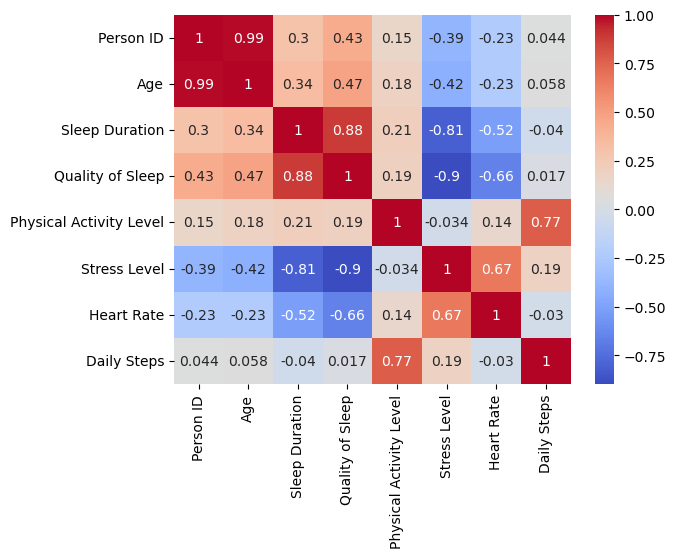

In [7]:
sns.heatmap(corr,annot=True,cmap='coolwarm')

In [8]:
health[['Systolic', 'Diastolic']] = health['Blood Pressure'].str.split('/', expand=True).astype(int)
health.drop(columns=['Blood Pressure', 'Person ID'], inplace=True)


In [9]:
categorical_cols = ['Gender', 'Occupation', 'BMI Category']
health = pd.get_dummies(health, columns=categorical_cols, drop_first=True)

label_encoder = LabelEncoder()
health['Sleep Disorder'] = label_encoder.fit_transform(health['Sleep Disorder'])

In [10]:
X = health.drop(columns=['Sleep Disorder'])
y = health['Sleep Disorder']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [12]:
 Counter(y_train)

Counter({1: 237, 0: 62})

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [15]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1])

In [16]:
y_pred = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred))

Accuracy: 0.973
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        15
           1       0.98      0.98      0.98        60

    accuracy                           0.97        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.97      0.97      0.97        75



## Logestic

In [17]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

model = LogisticRegression(max_iter=1000)
model.fit(X_resampled, y_resampled)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        15
           1       0.98      0.98      0.98        60

    accuracy                           0.97        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.97      0.97      0.97        75



In [18]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_resampled, y_resampled)

LogisticRegression(max_iter=1000)

In [19]:
y_pred_lr = logreg.predict(X_test)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        15
           1       0.98      0.98      0.98        60

    accuracy                           0.97        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.97      0.97      0.97        75



## KNN

In [20]:
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)


knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_resampled_scaled, y_resampled)


y_pred = knn.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[12  3]
 [ 0 60]]
              precision    recall  f1-score   support

           0       1.00      0.80      0.89        15
           1       0.95      1.00      0.98        60

    accuracy                           0.96        75
   macro avg       0.98      0.90      0.93        75
weighted avg       0.96      0.96      0.96        75



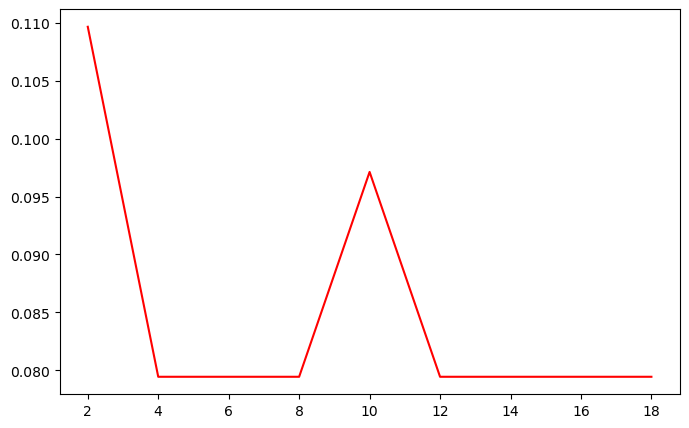

Optimal k based on max F1: 4


In [21]:
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled) 
X_test_scaled = scaler.transform(X_test)     


def elbow_method(k_values):
    errors = []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
        knn.fit(X_resampled_scaled, y_resampled)       
        y_pred = knn.predict(X_test_scaled)
        f1 = f1_score(y_test, y_pred, average='macro')
        errors.append(1 - f1)                         
    return errors


k_range = range(2, 20, 2)
testing_errors = elbow_method(k_range)


plt.figure(figsize=(8,5))
plt.plot(k_range, testing_errors, color='red')
plt.show()


optimal_k = k_range[testing_errors.index(min(testing_errors))]
print(f"Optimal k based on max F1: {optimal_k}")

In [22]:
knn_final = KNeighborsClassifier(n_neighbors=8, metric='euclidean')
knn_final.fit(X_resampled_scaled, y_resampled)


y_pred_final = knn_final.predict(X_test_scaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.93      0.88        15
           1       0.98      0.95      0.97        60

    accuracy                           0.95        75
   macro avg       0.90      0.94      0.92        75
weighted avg       0.95      0.95      0.95        75



## naive_bayes

In [23]:
nb = GaussianNB()
nb.fit(X_resampled_scaled, y_resampled)


y_pred = nb.predict(X_test_scaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.87      0.50        15
           1       0.95      0.60      0.73        60

    accuracy                           0.65        75
   macro avg       0.65      0.73      0.62        75
weighted avg       0.83      0.65      0.69        75



## SVM

In [24]:
svc = SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42)
svc.fit(X_resampled_scaled, y_resampled)

y_pred = svc.predict(X_test_scaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89        15
           1       0.95      1.00      0.98        60

    accuracy                           0.96        75
   macro avg       0.98      0.90      0.93        75
weighted avg       0.96      0.96      0.96        75



In [25]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}


grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=10,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_resampled_scaled, y_resampled)


best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best hyperparameters: {best_params}")
print(f"Best cross-validation accuracy: {best_score:.2f}")


best_svc = SVC(**best_params)
best_svc.fit(X_resampled_scaled, y_resampled)
y_pred_best = best_svc.predict(X_test_scaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Fitting 10 folds for each of 16 candidates, totalling 160 fits
Best hyperparameters: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation accuracy: 0.95

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90        15
           1       0.98      0.97      0.97        60

    accuracy                           0.96        75
   macro avg       0.93      0.95      0.94        75
weighted avg       0.96      0.96      0.96        75



In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


# KNN
y_pred_knn = knn.predict(X_test_scaled)

# Naive Bayes
y_pred_nb = nb.predict(X_test_scaled)

# SVC
y_pred_svc = svc.predict(X_test_scaled)


models = ['Logistic Regression', 'KNN', 'Naive Bayes', 'SVC']
y_preds = [y_pred_lr, y_pred_knn, y_pred_nb, y_pred_svc]

summary = []

for model_name, y_pred in zip(models, y_preds):
    summary.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
        'F1 Score': f1_score(y_test, y_pred, average='macro')
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.973333   0.958333  0.958333  0.958333
1                  KNN  0.960000   0.976190  0.900000  0.932249
2          Naive Bayes  0.653333   0.649360  0.733333  0.617347
3                  SVC  0.960000   0.976190  0.900000  0.932249
